I will probably plot two or three graphs for this, one based on just on the unblindedReadNodule level and the other will be based on the median malignancy ratings. I will use the existing csv files because running through the XML files all over again is probably inefficient. Last one could possible be based on soft labels

UnblindedReadNodule level

Looked through 0 slices
Looked through 200 slices
Looked through 300 slices
Looked through 700 slices
Looked through 1800 slices
Looked through 1900 slices
Looked through 2300 slices
Looked through 2600 slices
Looked through 4800 slices
Looked through 5900 slices
Looked through 6100 slices
Looked through 7100 slices
Looked through 7400 slices
Looked through 8000 slices
Looked through 8100 slices
Looked through 8200 slices
Looked through 8400 slices
Looked through 9400 slices
Looked through 10300 slices
Looked through 10800 slices
Looked through 11200 slices
Looked through 11400 slices
Looked through 11900 slices
Looked through 12600 slices
Looked through 12900 slices
Looked through 13600 slices
Looked through 13800 slices
Looked through 14700 slices
Looked through 14800 slices
Looked through 15400 slices
Looked through 16300 slices
Looked through 16400 slices
Looked through 17800 slices
Looked through 19200 slices
Looked through 19500 slices
Looked through 19800 slices
Looked through 2

([<matplotlib.axis.XTick at 0x116522fd0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

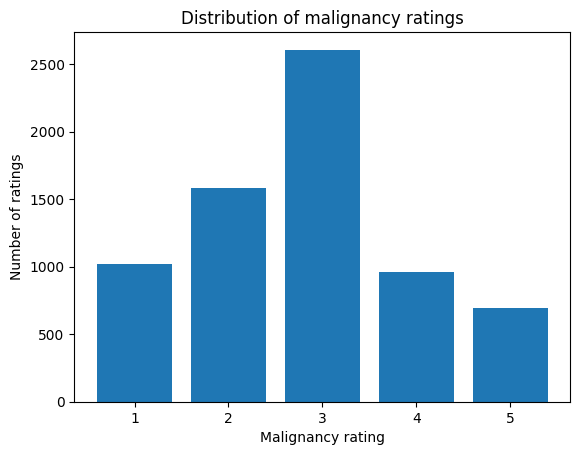

In [ ]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

project_folder = Path(os.getcwd()).parent
labels_roi_path = project_folder / "data" / "labels_roi.csv"
df = pd.read_csv(labels_roi_path)
malignancy_ratings = []
slices_ran_through = []

for index, row in df.iterrows():
    series_instance_uid = row["series_instance_uid"]
    nodule_id = row["nodule_id"]
    nodule_slice = [series_instance_uid, nodule_id]
    if nodule_slice in slices_ran_through:
        continue
    else:
        malignancy = int(row["malignancy"]) # Integer in this case because it is only 12345
        malignancy_ratings.append(malignancy)
        slices_ran_through.append(nodule_slice)
    
    if index % 100 == 0:
        print("Looked through", index, "slices")

counts = Counter(malignancy_ratings)

ratings = [1, 2, 3, 4, 5]
frequencies = [counts[rating] for rating in ratings]

plt.bar(ratings, frequencies)

plt.xlabel("Malignancy rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of malignancy ratings")

plt.xticks(ratings)

Distribution of median malignancy ratings (hard labels)

Looked through 0 nodules
Looked through 100 nodules
Looked through 200 nodules
Looked through 300 nodules
Looked through 400 nodules
Looked through 500 nodules
Looked through 600 nodules
Looked through 700 nodules
Looked through 800 nodules
Looked through 900 nodules
Looked through 1000 nodules
Looked through 1100 nodules
Looked through 1200 nodules
Looked through 1300 nodules
Looked through 1400 nodules
Looked through 1500 nodules
Looked through 1600 nodules
Looked through 1700 nodules
Looked through 1800 nodules


([<matplotlib.axis.XTick at 0x11521c690>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5')])

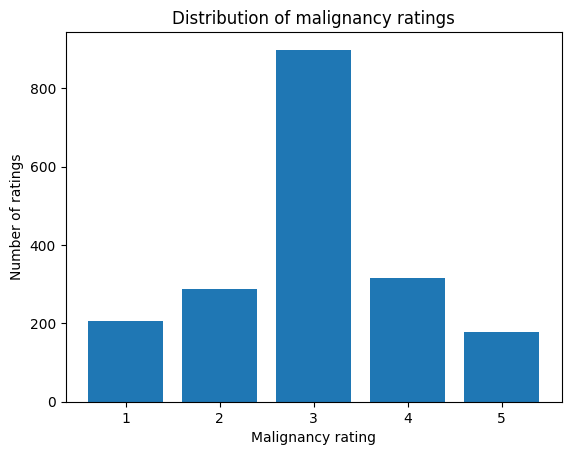

In [ ]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

project_folder = Path(os.getcwd()).parent
nodules_labels_path = project_folder / "data" / "nodules_labels.csv"
df = pd.read_csv(nodules_labels_path)
malignancy_ratings = []

for index, row in df.iterrows():
    malignancy = int(row["hard"]) # Integer in this case because it is only 12345
    malignancy_ratings.append(malignancy)
    
    if index % 100 == 0:
        print("Looked through", index, "nodules")

counts = Counter(malignancy_ratings)

ratings = [1, 2, 3, 4, 5]
frequencies = [counts[rating] for rating in ratings]

plt.bar(ratings, frequencies)

plt.xlabel("Malignancy rating")
plt.ylabel("Number of ratings")
plt.title("Distribution of median malignancy ratings")

plt.xticks(ratings)

Distribution of soft labels

Looked through 0 nodules
Looked through 100 nodules
Looked through 200 nodules
Looked through 300 nodules
Looked through 400 nodules
Looked through 500 nodules
Looked through 600 nodules
Looked through 700 nodules
Looked through 800 nodules
Looked through 900 nodules
Looked through 1000 nodules
Looked through 1100 nodules
Looked through 1200 nodules
Looked through 1300 nodules
Looked through 1400 nodules
Looked through 1500 nodules
Looked through 1600 nodules
Looked through 1700 nodules
Looked through 1800 nodules


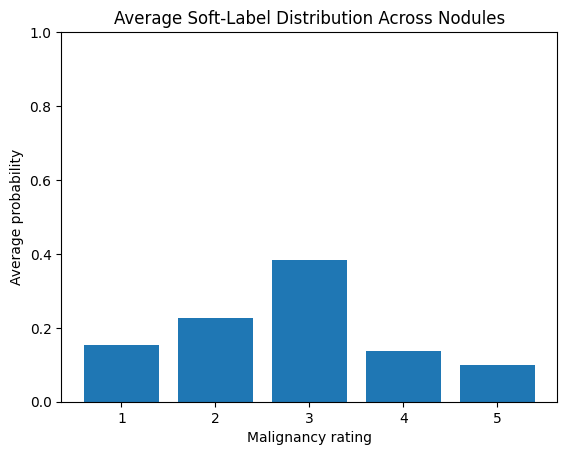

In [ ]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_folder = Path(os.getcwd()).parent
nodules_labels_path = project_folder / "data" / "nodules_labels.csv"
df = pd.read_csv(nodules_labels_path)

soft_labels = []

for index, row in df.iterrows():
    probabilities = [
        row["soft_1"],
        row["soft_2"],
        row["soft_3"],
        row["soft_4"],
        row["soft_5"]
    ]

    soft_labels.append(probabilities)

    if index % 100 == 0:
        print("Looked through", index, "nodules")

average_probabilities = df[
    ["soft_1", "soft_2", "soft_3", "soft_4", "soft_5"]
].mean()

ratings = [1, 2, 3, 4, 5]
probabilities = average_probabilities.tolist()

plt.bar(ratings, probabilities)

plt.xlabel("Malignancy rating")
plt.ylabel("Average probability")
plt.title("Average Soft-Label Distribution Across Nodules")

plt.xticks(ratings)
plt.ylim(0, 1)

plt.show()